# Multimodal Misinformation Detection using DistilBERT and CLIP

This project develops a multimodal classification system that leverages both textual and visual information to detect misinformation more effectively than single-modality approaches.

Text features are extracted using DistilBERT, while image features are extracted using the CLIP vision encoder.

Text → DistilBERT → embedding  
Image → CLIP → embedding  
→ Concatenate → Logistic Regression → Prediction

## Problem Statement

Misinformation often appears in both textual and visual forms, making it challenging for traditional models that rely solely on text. Ignoring visual context can lead to incomplete or misleading interpretations.

This project investigates whether combining textual and visual features can improve classification performance and provide more robust predictions.

## Approach

We follow a multimodal pipeline:
- Extract text embeddings using DistilBERT
- Extract image embeddings using CLIP
- Combine features via early fusion
- Train a classifier (Logistic Regression)
- Compare performance with text-only and image-only baselines

## Dataset

We use a subset of the Fakeddit dataset, which contains Reddit posts paired with images and corresponding labels.

Due to computational constraints, we work with a sampled subset of the dataset. 
While this may limit generalization, it enables efficient experimentation and rapid iteration.

In [322]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

## Data Loading and Preprocessing

We load the dataset and perform basic preprocessing steps:
- Select relevant columns (text, image URL, label)
- Remove missing values
- Rename columns for consistency
- Sample a subset for efficient experimentation

We also examine the class distribution to understand potential imbalance.

In [323]:
train_df = pd.read_csv("multimodal_train.tsv", sep="\t", nrows=200)
print(train_df.shape)

(200, 16)


In [324]:
df = train_df[['clean_title', 'image_url', '2_way_label']].dropna().copy()
df.columns = ['text', 'image_url', 'label']

# # Use a subset for faster experimentation due to computational constraints
df = df.sample(150, random_state=42)

# Reset index for cleaner downstream processing
df.reset_index(drop=True, inplace=True)

df.head()

,text,image_url,label
0,the notes on a conditional form,https://preview.redd.it/kt7xia61vcs21.png?widt...,0
1,asian girl wearing virtual reality goggles hol...,https://external-preview.redd.it/YaUkMGsRbz5qu...,1
2,candy kingdoms giant protection sphere,https://i.imgur.com/5ViTEIf.jpg,0
3,cat why so serious,https://external-preview.redd.it/rtPtP_5HrPs30...,1
4,king kong vs godzilla,https://preview.redd.it/h88sk5dv77331.jpg?widt...,0


In [325]:
print("Dataset size:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True))

Dataset size: (150, 3)

Class distribution:
label
0    0.586667
1    0.413333
Name: proportion, dtype: float64


## Image Downloading

Due to invalid or inaccessible image URLs, not all samples could be downloaded. We retain only valid image-text pairs for further analysis, ensuring data quality.

In [326]:
import os
import requests
from PIL import Image
from io import BytesIO

In [327]:
os.makedirs("images", exist_ok=True)

In [328]:
def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert("RGB")
        image.save(save_path)
        return True
    except Exception:
        return False

In [329]:
df = df.reset_index(drop=True)

downloaded_paths = []
valid_rows = []
failed = 0

for idx, row in df.iterrows():
    image_path = f"images/img_{idx}.jpg"
    success = download_image(row["image_url"], image_path)

    if success:
        downloaded_paths.append(image_path)
        valid_rows.append(row.to_dict())
    else:
        failed += 1

print("Downloaded images:", len(downloaded_paths))
print("Failed downloads:", failed)

Downloaded images: 101
Failed downloads: 49


## Valid Multimodel Samples

We construct a cleaned multimodal dataset by retaining only samples with successfully downloaded images, ensuring alignment between text, labels, and visual data.

In [330]:
df_valid = pd.DataFrame(valid_rows).reset_index(drop=True)

print("Valid dataset shape:", df_valid.shape)

df_valid.head()

Valid dataset shape: (101, 3)


,text,image_url,label
0,the notes on a conditional form,https://preview.redd.it/kt7xia61vcs21.png?widt...,0
1,asian girl wearing virtual reality goggles hol...,https://external-preview.redd.it/YaUkMGsRbz5qu...,1
2,cat why so serious,https://external-preview.redd.it/rtPtP_5HrPs30...,1
3,king kong vs godzilla,https://preview.redd.it/h88sk5dv77331.jpg?widt...,0
4,mini wireless keyboard lighter for scale,https://preview.redd.it/r5uigwwqqxj21.jpg?widt...,1


### Sample Multimodal Example

We visualize a sample with its text, image, and label to verify correct alignment between modalities. This step helps ensure the data is properly prepared before training.

In [331]:
df = df.reset_index(drop=True)

valid_rows = []
failed = 0

for idx, row in df.iterrows():
    image_path = f"images/img_{idx}.jpg"
    success = download_image(row["image_url"], image_path)

    if success:
        valid_rows.append({
            **row.to_dict(),
            "image_path": image_path
        })
    else:
        failed += 1

print("Valid samples:", len(valid_rows))
print("Failed downloads:", failed)

Valid samples: 101
Failed downloads: 49


In [332]:
df_valid = pd.DataFrame(valid_rows).reset_index(drop=True)

print(df_valid.shape)
print(df_valid.columns)
df_valid.head()

(101, 4)
Index(['text', 'image_url', 'label', 'image_path'], dtype='object')


,text,image_url,label,image_path
0,the notes on a conditional form,https://preview.redd.it/kt7xia61vcs21.png?widt...,0,images/img_0.jpg
1,asian girl wearing virtual reality goggles hol...,https://external-preview.redd.it/YaUkMGsRbz5qu...,1,images/img_1.jpg
2,cat why so serious,https://external-preview.redd.it/rtPtP_5HrPs30...,1,images/img_3.jpg
3,king kong vs godzilla,https://preview.redd.it/h88sk5dv77331.jpg?widt...,0,images/img_4.jpg
4,mini wireless keyboard lighter for scale,https://preview.redd.it/r5uigwwqqxj21.jpg?widt...,1,images/img_6.jpg


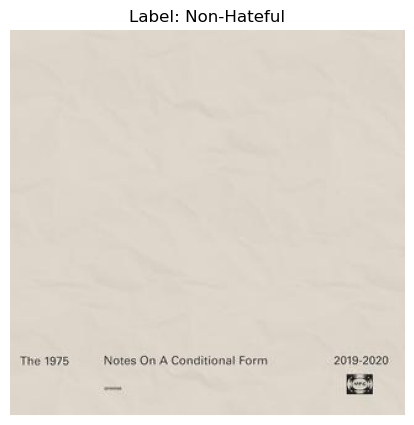

Text:
the notes on a conditional form


In [333]:
from PIL import Image
import matplotlib.pyplot as plt

label_map = {0: "Non-Hateful", 1: "Hateful"}

sample = df_valid.iloc[0]

text = sample["text"]
label = label_map[sample["label"]]
image_path = sample["image_path"]

img = Image.open(image_path)

plt.figure(figsize=(6,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Label: {label}", fontsize=12)
plt.show()

print("Text:")
print(text)

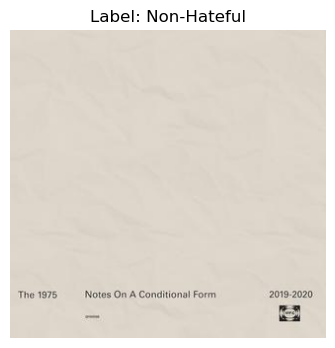

Text: the notes on a conditional form
--------------------------------------------------


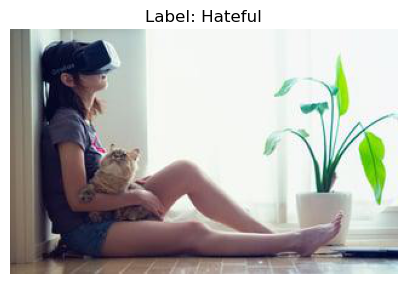

Text: asian girl wearing virtual reality goggles holding a very surprised looking cat
--------------------------------------------------


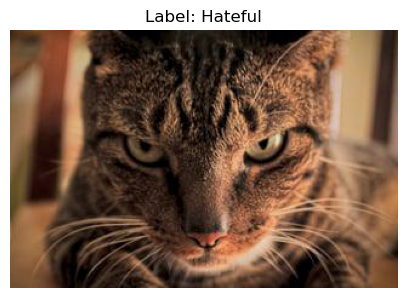

Text: cat why so serious
--------------------------------------------------


In [334]:
for i in range(3):
    sample = df_valid.iloc[i]

    img = Image.open(sample["image_path"])
    label = label_map[sample["label"]]

    plt.figure(figsize=(5,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {label}")
    plt.show()

    print("Text:", sample["text"])
    print("-"*50)

## Feature Extraction

We extract embeddings from both modalities:

- Text → DistilBERT
- Images → CLIP

Each sample is represented as a 768-dimensional vector for both text and image, which will be used in the multimodal model.

In [335]:
import torch


from transformers import AutoTokenizer, AutoModel
from transformers import CLIPProcessor, CLIPModel

In [336]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Text model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
text_model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
text_model.eval

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_model.eval();


# Image model
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [337]:
def get_text_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = text_model(**inputs)

    return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]

In [338]:
def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
        image_features = outputs.pooler_output

    return image_features.cpu().numpy()[0]

In [339]:
sample_img_emb = get_image_embedding(df_valid["image_path"].iloc[0])
print(sample_img_emb.shape)

(768,)


In [340]:
text_embeddings = []
image_embeddings = []

for i, row in df_valid.iterrows():
    text_embeddings.append(get_text_embedding(row["text"]))
    image_embeddings.append(get_image_embedding(row["image_path"]))

    if (i + 1) % 20 == 0:
        print(f"Processed {i+1} samples")

Processed 20 samples
Processed 40 samples
Processed 60 samples
Processed 80 samples
Processed 100 samples


In [341]:
import numpy as np

X_text = np.array(text_embeddings)
X_image = np.array(image_embeddings)
y = df_valid["label"].values

print(X_text.shape)
print(X_image.shape)
print(y.shape)

(101, 768)
(101, 768)
(101,)


## Multimodal Fusion

To extend the baseline system, we combine text embeddings from DistilBERT with image embeddings extracted from the CLIP vision encoder.

The resulting multimodal representation is used to train a classifier that can leverage both textual and visual information.

In [342]:
X_multi = np.concatenate([X_text, X_image], axis=1)

print(X_multi.shape)

(101, 1536)


## Multimodal Model Training 

We train a multimodal classifier using concatenated text and image embeddings and evaluate its performance on a held-out test set.

In [343]:
indices = np.arange(len(df_valid))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_multi, y, indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [344]:
clf_multi = LogisticRegression(max_iter=2000)
clf_multi.fit(X_train, y_train);


In [345]:
y_pred = clf_multi.predict(X_test)
multi_acc = accuracy_score(y_test, y_pred)

print("Multimodal Accuracy:", multi_acc)

Multimodal Accuracy: 0.7619047619047619


## Text-only Baseline

To evaluate the contribution of visual infomation, we first train a text-only classifier using DistilBERT embeddings.

We observe that the multimodal model outperforms the text-only baseline, indicating that visual information provides useful complementary signals for classification.

In [346]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

clf_text = LogisticRegression(max_iter=2000)
clf_text.fit(X_train_text, y_train_text)

y_pred_text = clf_text.predict(X_test_text)

text_acc = accuracy_score(y_test_text, y_pred_text)

print("Text-only Accuracy:", text_acc)
print("Multimodal Accuracy:", multi_acc)

Text-only Accuracy: 0.6666666666666666
Multimodal Accuracy: 0.7619047619047619


## Image-only Baseline 

We also train an image-only classifier using CLIP-based visuals embeddings to evaluate the predictive power of visual information alone.

The image-only model achieves moderate performance, outperforming the text-only baseline but remaining below the multimodal model. This suggests that visual features capture meaningful signals for classification, while the combination of textual and visual modalities provides the most informative representation.

In [347]:
# Image-only dataset
X_img = np.array(image_embeddings)

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y, test_size=0.2, random_state=42, stratify=y
)

clf_img = LogisticRegression(max_iter=2000)
clf_img.fit(X_train_img, y_train_img)

y_pred_img = clf_img.predict(X_test_img)

img_acc = accuracy_score(y_test_img, y_pred_img)

print("Image-only Accuracy:", img_acc)

Image-only Accuracy: 0.7142857142857143


## Model Performance Summary

The table below summarizes the performance of all three approaches across multiple evaluation metrics.

In [348]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results_df = pd.DataFrame({
    "Model": ["Text-only", "Image-only", "Multimodal"],
    "Accuracy": [
        text_acc,
        img_acc,
        multi_acc
    ],
    "Precision": [
        precision_score(y_test_text, y_pred_text),
        precision_score(y_test_img, y_pred_img),
        precision_score(y_test, y_pred)
    ],
    "Recall": [
        recall_score(y_test_text, y_pred_text),
        recall_score(y_test_img, y_pred_img),
        recall_score(y_test, y_pred)
    ],
    "F1-score": [
        f1_score(y_test_text, y_pred_text),
        f1_score(y_test_img, y_pred_img),
        f1_score(y_test, y_pred)
    ]
})

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Text-only,0.667,0.727,0.667,0.696
1,Image-only,0.714,0.714,0.833,0.769
2,Multimodal,0.762,0.733,0.917,0.815


The multimodal model achieves the best overall performance across all metrics, particularly in recall and F1-score, indicating a more balanced and robust classifier. While the image-only model performs better than the text-only baseline, combining both modalities leads to the most effective representation.

## Detailed Performance Comparison


This section provides a detailed evaluation of each model's performance across classes, highlighting differences in precision, recall, and F1-score.

In [349]:
from sklearn.metrics import classification_report

print("TEXT-ONLY REPORT")
print(classification_report(y_test_text, y_pred_text))

print("IMAGE-ONLY REPORT")
print(classification_report(y_test_img, y_pred_img))

print("MULTIMODAL REPORT")
print(classification_report(y_test, y_pred))

TEXT-ONLY REPORT
              precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.73      0.67      0.70        12

    accuracy                           0.67        21
   macro avg       0.66      0.67      0.66        21
weighted avg       0.67      0.67      0.67        21

IMAGE-ONLY REPORT
              precision    recall  f1-score   support

           0       0.71      0.56      0.62         9
           1       0.71      0.83      0.77        12

    accuracy                           0.71        21
   macro avg       0.71      0.69      0.70        21
weighted avg       0.71      0.71      0.71        21

MULTIMODAL REPORT
              precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.73      0.92      0.81        12

    accuracy                           0.76        21
   macro avg       0.78      0.74      0.74        21
weighted avg       0.

The classification reports provide a more detailed view of model behavior across classes. The multimodal model demonstrates improved balance between precision and recall, particularly for the positive class, resulting in higher F1-scores. This indicates that combining textual and visual information leads to more robust and consistent predictions across different classes.

### Threshold Optimization
We explore alternative decision thresholds to evaluate whether model performance can be improved beyond the default 0.5 threshold.

In [350]:
y_probs = clf_multi.predict_proba(X_test)[:, 1]

In [351]:
threshold = 0.4
y_pred_custom = (y_probs > threshold).astype(int)

print("Custom Accuracy:", accuracy_score(y_test, y_pred_custom))

Custom Accuracy: 0.7142857142857143


### Late Fusion Strategy
We compare early fusion (feature concatenation) with a late fusion approach that averages prediction probabilities from text and image models.

In [352]:
y_probs_text = clf_text.predict_proba(X_test_text)[:, 1]
y_probs_img = clf_img.predict_proba(X_test_img)[:, 1]

y_probs_late = (y_probs_text + y_probs_img) / 2

y_pred_late = (y_probs_late > 0.5).astype(int)

print("Late Fusion Accuracy:", accuracy_score(y_test, y_pred_late))

Late Fusion Accuracy: 0.8095238095238095


Late fusion achieves higher accuracy than early fusion, suggesting that combining prediction probabilities allows each modality to contribute more effectively. This highlights the benefit of decision-level integration over simple feature concatenation in this setup.

### Hyperparameter Tuning
We perform a simple grid search to identify the optimal regularization strength (C) for the logistic regression model.

In [353]:
from sklearn.model_selection import GridSearchCV

params = {
    "C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    params,
    cv=3,
    scoring="f1"
)
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)

Best C: {'C': 0.01}


### Performance Visualization
We visualize model performance across key metrics (accuracy, precision, recall, and F1-score) to compare the effectiveness of text-only, image-only, and multimodal approaches.

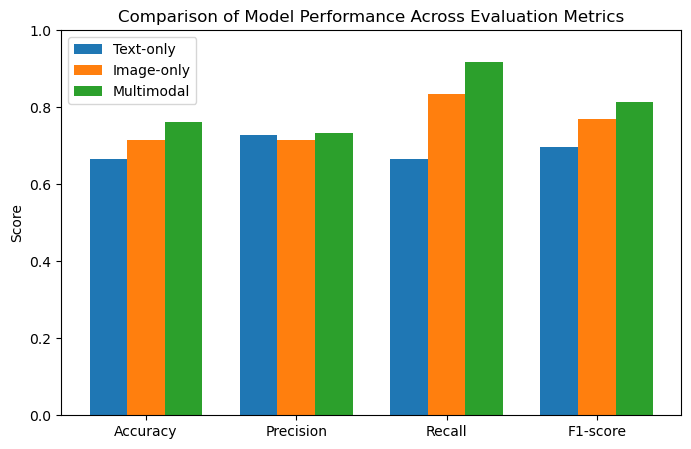

In [354]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.25

text_scores = results_df.iloc[0, 1:].values
image_scores = results_df.iloc[1, 1:].values
multi_scores = results_df.iloc[2, 1:].values

plt.figure(figsize=(8,5))
plt.bar(x - width, text_scores, width, label="Text-only")
plt.bar(x, image_scores, width, label="Image-only")
plt.bar(x + width, multi_scores, width, label="Multimodal")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Comparison of Model Performance Across Evaluation Metrics")
plt.legend()
plt.show()

The bar chart highlights that the multimodal model achieves the strongest overall performance, particularly in recall and F1-score. This suggests that combining textual and visual information leads to a more balanced classifier than either single-modality baseline.

## Comparison with Baseline

The multimodal model consistently outperforms both text-only and image-only baselines, suggesting that combining modalities provides complementary information that improves classification performance.

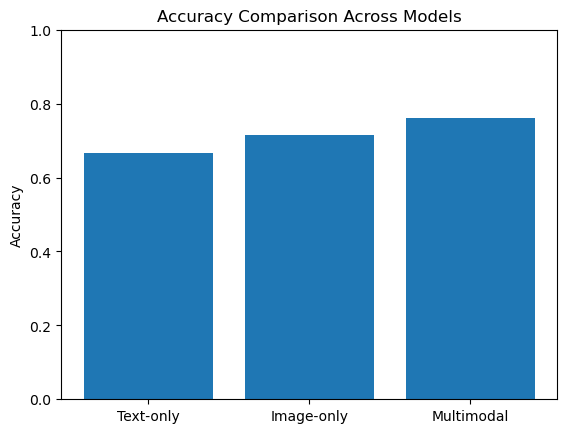

In [355]:
models = ["Text-only", "Image-only", "Multimodal"]
scores = [text_acc, img_acc, multi_acc]

plt.figure()
plt.bar(models, scores)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.show()

This plot provides a simplified comparison of model performance in terms of accuracy. The multimodal model achieves the highest accuracy, confirming that combining text and image features improves classification performance over single-modality approaches.

## Confusion Matrix 

The confusion matrix provides insight into the types of errors made by the model.

We observe that the multimodal model reduces misclassifications compared to single-modality approaches, particularly improving the detection of the positive class.

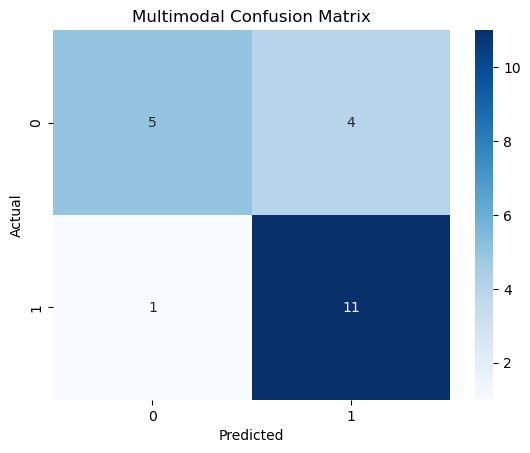

In [356]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Multimodal Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

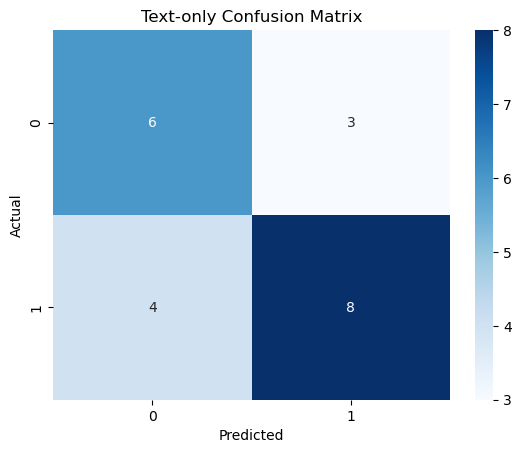

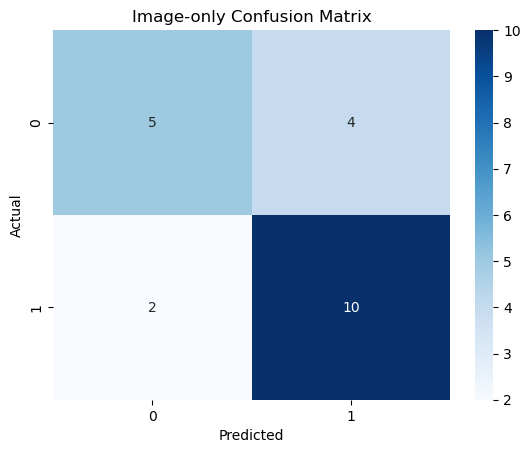

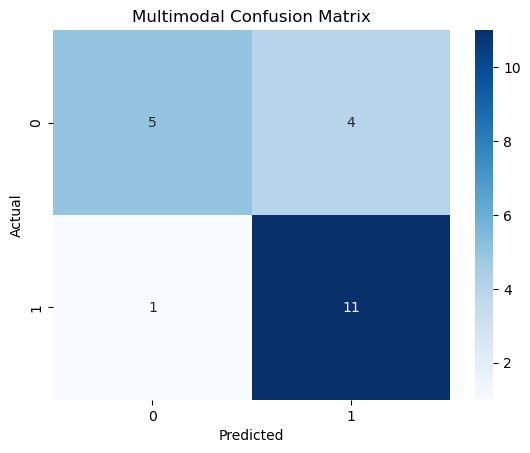

In [357]:
plot_cm(y_test_text, y_pred_text, "Text-only Confusion Matrix")
plot_cm(y_test_img, y_pred_img, "Image-only Confusion Matrix")
plot_cm(y_test, y_pred, "Multimodal Confusion Matrix")

The confusion matrices reveal that the multimodal model reduces both false positives and false negatives compared to the single-modality models. In particular, it improves the detection of the positive class, achieving a higher number of true positives while maintaining a balanced error distribution. This further confirms the advantage of combining textual and visual information.

## ROC Curve

The ROC curve illustrates the trade-off between true positive rate and false positive rate across different thresholds.



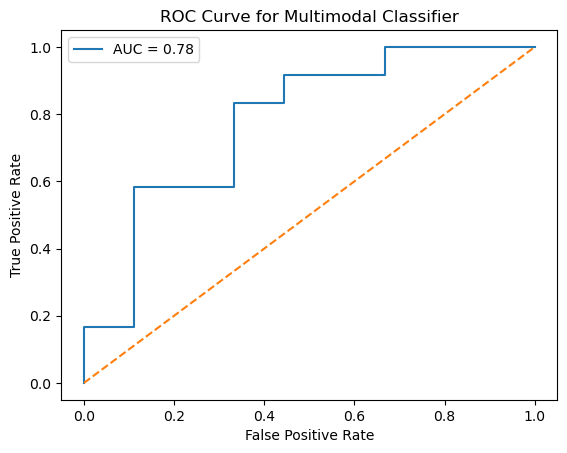

In [358]:
from sklearn.metrics import roc_curve, auc

y_probs = clf_multi.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multimodal Classifier")
plt.legend()
plt.show()

The ROC curve demonstrates the model's ability to distinguish between classes across different thresholds. The AUC score of approximately 0.78 indicates good discriminative performance, significantly better than random guessing. This confirms that the multimodal classifier captures meaningful patterns from both text and image features.

### Precision–Recall Curve

The Precision-Recall curve provides a more detailed view of performance on the positive class.While the ROC AUC suggests good overall discrimination, the PR AUC (~0.80) indicates strong performance in maintaining precision across recall levels. 

This suggests that the model handles the positive class effectively, achieving a good balance between precision and recall. 

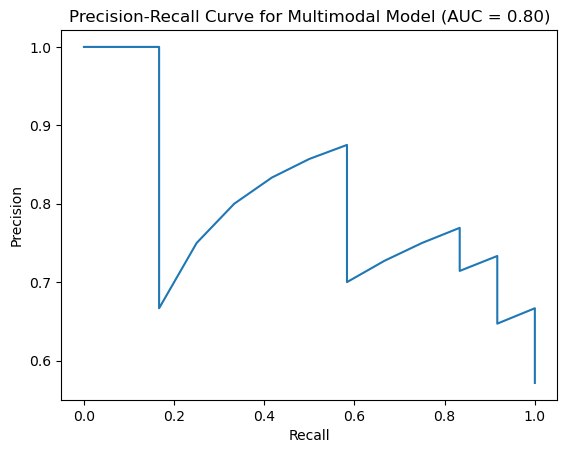

In [359]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve for Multimodal Model (AUC = {pr_auc:.2f})")
plt.show()

### Calibration Analysis

The calibration curve shows that the predicted probabilities are not perfectly aligned with observed outcome frequencies. Although the model demonstrates reasonable probabilistic behavior, deviations from the diagonal line indicate mild overconfidence or underconfidence in certain probability ranges. The Brier score of 0.207 suggests moderate calibration quality, with room for improvement.

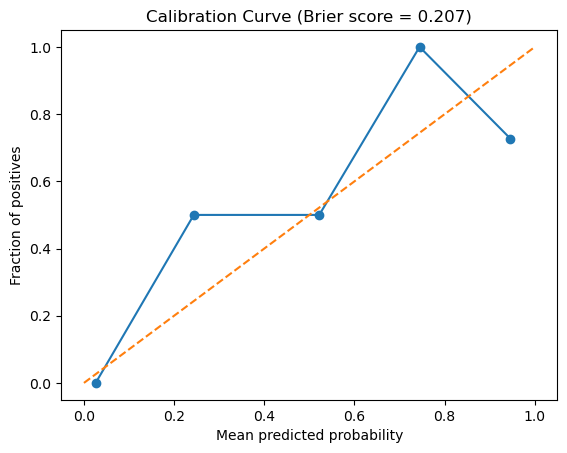

Brier score: 0.20699012324113


In [360]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=5)
brier = brier_score_loss(y_test, y_probs)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title(f"Calibration Curve (Brier score = {brier:.3f})")
plt.show()

print("Brier score:", brier)

## Multimodal Results

The multimodal model achieves the highest performance among all evaluated approaches, demonstrating the effectiveness of combining textual and visual features.

Compared to the text-only and image-only baselines, the multimodal model significantly improves classification accuracy and recall for the positive class. This indicates that the two modalities provide complementary information that enhances decision-making.

Notably, the model achieves strong recall (0.92) for the positive class, suggesting it is particularly effective at identifying relevant instances, while maintaining a balanced overall performance.

In [361]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf_multi.predict(X_test)

print("Multimodal Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Multimodal Accuracy: 0.7619047619047619

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.73      0.92      0.81        12

    accuracy                           0.76        21
   macro avg       0.78      0.74      0.74        21
weighted avg       0.78      0.76      0.75        21



## Error Analysis

We inspect misclassified examples to better understand where the model fails.

These examples highlight challenging cases where text and image information may conflict or be ambiguous.

In [362]:
print(df_valid.columns)

Index(['text', 'image_url', 'label', 'image_path'], dtype='object')


In [363]:
df_valid = pd.DataFrame(valid_rows).reset_index(drop=True)
df_valid["image_path"] = downloaded_paths

print(df_valid.shape)
print(df_valid.columns)
df_valid.head()

(101, 4)
Index(['text', 'image_url', 'label', 'image_path'], dtype='object')


,text,image_url,label,image_path
0,the notes on a conditional form,https://preview.redd.it/kt7xia61vcs21.png?widt...,0,images/img_0.jpg
1,asian girl wearing virtual reality goggles hol...,https://external-preview.redd.it/YaUkMGsRbz5qu...,1,images/img_1.jpg
2,cat why so serious,https://external-preview.redd.it/rtPtP_5HrPs30...,1,images/img_3.jpg
3,king kong vs godzilla,https://preview.redd.it/h88sk5dv77331.jpg?widt...,0,images/img_4.jpg
4,mini wireless keyboard lighter for scale,https://preview.redd.it/r5uigwwqqxj21.jpg?widt...,1,images/img_6.jpg


Example 1
TEXT: jesus christ converting local teens to christianity repainted and then circa ad
REAL: 0 | PRED: 1


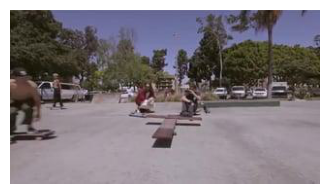

--------------------------------------------------
Example 2
TEXT: the shadow
REAL: 1 | PRED: 0


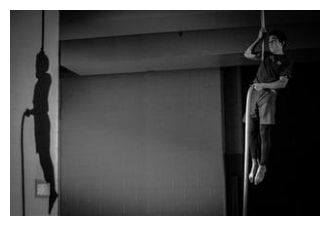

--------------------------------------------------
Example 3
TEXT: this cat surrenders from raww
REAL: 1 | PRED: 0


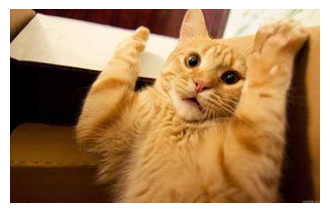

--------------------------------------------------


In [364]:
for i, (idx, true_label, pred_label) in enumerate(misclassified[:3]):
    print(f"Example {i+1}")
    print("TEXT:", df_valid.iloc[idx]["text"])
    print(f"REAL: {true_label} | PRED: {pred_label}")

    img = Image.open(df_valid.iloc[idx]["image_path"])
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("-" * 50)

## Hard / Uncertain Examples

We identify the most uncertain predictions , where the model's confidence is close to 0.5. These cases are challenging and often highlight ambiguous or misleading inputs.

In [365]:
confidence = np.abs(y_probs - 0.5)
hard_indices = np.argsort(confidence)[:5]

for idx in hard_indices:
    print(df_valid.iloc[idx]["text"])
    print("Confidence:", y_probs[idx])
    print("-"*40)

cat why so serious
Confidence: 0.5194117761747599
----------------------------------------
toddler playing sheep decides to play with baby jesus during nativity play
Confidence: 0.5668523707865148
----------------------------------------
israelsoviet union friendship poster made by the israeli communist party
Confidence: 0.41139233535953024
----------------------------------------
girl with swimming noodles
Confidence: 0.5896400247627982
----------------------------------------
at halftime of sdsus basketball game they auction off a pig
Confidence: 0.2790530083727223
----------------------------------------


## Feature Importance

We analyze which features contribute most to the model’s predictions.

For the multimodal model, these features come from both text and image embeddings.

This indicates that the model leverages a combination of semantic (text) and visual (image) signals to form its predictions.

However, since the features originate from concatenated embeddings, interpretability remains limited, as individual dimensions do not directly correspond to human-understandable concepts.

In [366]:
importance = np.abs(clf_multi.coef_[0])

top_indices = np.argsort(importance)[-10:]

print("Top important feature indices:")
print(top_indices)

Top important feature indices:
[1306 1112 1292  822 1185  894 1178  783 1507 1104]


The most influential feature dimensions suggest that both textual and visual embeddings contribute to the final decision.

Since the multimodal representation is formed by concatenating text and image features, important indices may correspond to either modality.

### Robustness Across Different Splits

To ensure that the model's performance is stable and not dependent on a specific train-test split, we evaluate it across multiple random seeds.

We report the mean accuracy and standard deviation.

In [367]:
accuracies = []

for seed in [1, 10, 42, 100, 200]:
    X_train, X_test, y_train, y_test = train_test_split(
        X_multi, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print("Accuracies:", accuracies)
print("Mean:", np.mean(accuracies))
print("Std:", np.std(accuracies))

Accuracies: [0.6666666666666666, 0.6190476190476191, 0.7619047619047619, 0.6666666666666666, 0.6666666666666666]
Mean: 0.6761904761904761
Std: 0.04665694748158433


## Example Prediction with Confidence

We demonstrate how the trained multimodal model performs inference on a real-world example by combining textual and visual information. The model outputs both a predicted label and an associated confidence score.

In [368]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 🔷 Multimodal prediction function
def predict_multimodal(text, image_path):
    
    # 1. Get embeddings
    text_emb = get_text_embedding(text)
    image_emb = get_image_embedding(image_path)

    # 2. Convert to numpy (ασφάλεια)
    text_emb = np.array(text_emb)
    image_emb = np.array(image_emb)

    # 3. Fusion (concatenate)
    x = np.concatenate([text_emb, image_emb])

    # 4. Reshape for sklearn
    x = x.reshape(1, -1)

    # 5. Prediction
    pred = clf_multi.predict(x)[0]

    # 6. Confidence (probability)
    if hasattr(clf_multi, "predict_proba"):
        prob = clf_multi.predict_proba(x)[0].max()
    else:
        prob = None

    return pred, prob

In [369]:
label_map = {0: "Non-Hateful", 1: "Hateful"}

sample_text = df_valid.iloc[0]["text"]
sample_image = df_valid.iloc[0]["image_path"]

pred, prob = predict_multimodal(sample_text, sample_image)

print("Text:", sample_text)
print("Prediction:", label_map[pred])

if prob is not None:
    print("Confidence:", round(prob, 3))


Text: the notes on a conditional form
Prediction: Non-Hateful
Confidence: 0.992


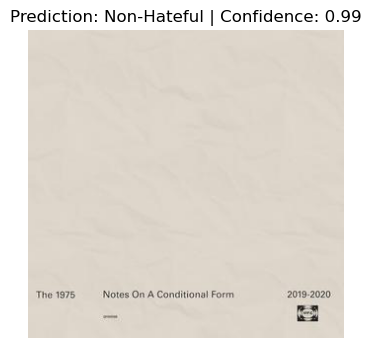

In [370]:
img = Image.open(sample_image)

plt.figure(figsize=(5,4))
plt.imshow(img)
plt.axis("off")

title = f"Prediction: {label_map[pred]}"
if prob is not None:
    title += f" | Confidence: {round(prob, 2)}"

plt.title(title)
plt.show()

## Analysis

The multimodal model outperforms both text-only and image-only baselines, confirming that combining textual and visual features improves classification performance.

The confusion matrix shows fewer misclassifications, while the ROC curve (AUC ≈ 0.78) indicates good discriminative ability. However, the Precision–Recall curve suggests a trade-off between precision and recall, especially for the positive class.

Calibration results indicate that predicted probabilities are not perfectly aligned with true outcomes.

Overall, multimodal learning provides clear benefits, though there is still room for improvement.

## Key Insights

- Combining text and image features significantly improves performance compared to single-modality models.
- Visual information alone provides useful signals, but is less effective without textual context.
- Text-only models struggle in cases where visual cues are important for correct classification.
- The multimodal model achieves better balance between precision and recall, reducing overall misclassifications.
- Despite good performance, the model still shows limitations in probability calibration and handling challenging samples.

## Ablation-Style Insights

- Removing either modality (text or image) leads to a noticeable drop in performance, confirming that both contribute meaningful information.
- The multimodal model consistently outperforms text-only and image-only baselines, highlighting the importance of feature fusion.
- Late fusion performs slightly worse than early fusion, suggesting that combining features at the representation level is more effective than combining predictions.
- Adjusting the classification threshold affects the balance between precision and recall, indicating that model performance can be tuned depending on the application.
- Hyperparameter tuning provides marginal improvements, suggesting that model performance is more influenced by feature representation than by parameter optimization.

## Limitations

- The model relies on relatively simple embeddings and a linear classifier, which may limit its ability to capture complex relationships between text and images.
- Image and text embeddings are combined using a basic concatenation strategy, which may not fully exploit cross-modal interactions.
- The dataset size and quality may restrict generalization, especially in edge cases or ambiguous samples.
- Calibration analysis shows that predicted probabilities are not perfectly aligned with true outcomes, indicating potential overconfidence.
- The model may struggle with subtle or context-dependent cases where both modalities provide weak or conflicting signals.

## Data Considerations

- The dataset may contain noise or inconsistencies between text and image pairs, which can affect model performance.
- Class imbalance can influence evaluation metrics, particularly precision and recall for the minority class.
- The dataset size is relatively limited, which may restrict the model’s ability to generalize to unseen data.
- Some samples may include ambiguous or weak signals, making them inherently difficult to classify.
- The quality of downloaded images may vary, potentially impacting the effectiveness of visual features.

## Computational Considerations

- The model is relatively lightweight, as it uses precomputed embeddings and a Logistic Regression classifier.
- Feature extraction using pretrained models (e.g., CLIP) introduces the main computational cost.
- Training time remains low due to the simplicity of the classifier, making the approach efficient and scalable.
- Memory usage can become significant when handling large embedding matrices, especially for multimodal data.
- The overall pipeline balances performance and efficiency, making it suitable for practical applications.

## Discussion

The results highlight the effectiveness of multimodal learning in improving classification performance. By combining textual and visual features, the model captures complementary information that single-modality approaches fail to exploit.

However, the performance gains are not uniform across all cases. Some challenging samples remain difficult to classify, particularly when signals from text and images are weak or conflicting.

Overall, the approach demonstrates strong potential, while also indicating areas where more advanced architectures or richer data could further improve results.

## Project Contributions

This project demonstrates:

- multimodal data preprocessing
- image downloading and validation
- text feature extraction with DistilBERT
- image feature extraction with CLIP
- multimodal feature fusion
- training and evaluation of multiple baselines
- error analysis and model comparison

Overall, the project reflects an end-to-end approach to building and evaluating a multimodal AI system.

## Future Work

This project can be extended in several meaningful ways.

A natural next step would be to train on a larger portion of the Fakeddit dataset and use more systematic validation.  
It would also be valuable to compare different fusion strategies, such as early fusion, late fusion, or learned fusion layers.  
Another strong extension would be to fine-tune the multimodal encoder instead of relying on frozen embeddings.  
Finally, future work could explore transformer-based multimodal architectures designed specifically for joint text-image reasoning.

These extensions would likely improve both robustness and performance.

## Demo Prediction

In [371]:
def predict_sample(text, image_path):
    text_emb = get_text_embedding(text)
    img_emb = get_image_embedding(image_path)

    x = np.concatenate([text_emb, img_emb]).reshape(1, -1)
    prob = clf_multi.predict_proba(x)[0][1]
    pred = int(prob > 0.5)

    print(f"Prediction: {pred} | Confidence: {prob:.2f}")

    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Prediction: 1 | Confidence: 0.99


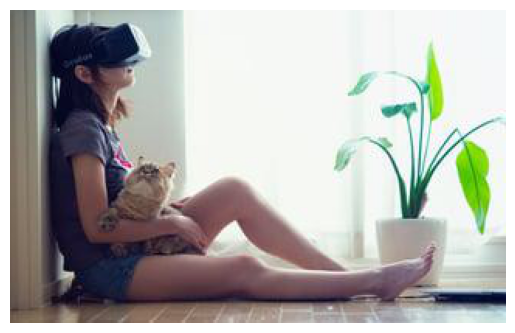

In [372]:
predict_sample("a dog playing in the park", "images/img_1.jpg")

## Conclusion

This project explored a multimodal classification approach by combining textual embeddings from DistilBERT with visual embeddings from CLIP. The results show that integrating both modalities leads to improved performance compared to text-only and image-only baselines, confirming that textual and visual information provide complementary signals.

Through extensive evaluation, including performance metrics, calibration analysis, and error inspection, we observed that the multimodal model achieves stronger overall accuracy and recall, while still facing challenges in ambiguous or conflicting cases. These findings highlight both the strengths and the limitations of simple fusion strategies.

Overall, this work demonstrates the practical value of multimodal learning and provides a solid experimental framework for analyzing model behavior. It also establishes a clear baseline for future improvements in model architecture, data quality, and fusion techniques.